In [1]:
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
import yaml
from pyoperators import (
    MPI,
    Operator,
    flags,
    BlockDiagonalOperator,
    BlockColumnOperator,
    CompositionOperator,
    BlockRowOperator,
    DiagonalOperator,
    IdentityOperator,
    ReshapeOperator,
    DenseOperator,
)
from pyoperators.iterative.core import AbnormalStopIteration

import qubic
from qubic.lib.Instrument.Qacquisition import QubicInstrumentType
from qubic.lib.MapMaking.Qatmosphere import AtmosphereMaps, WindPerturbation
from qubic.lib.MapMaking.Qcg_test_for_atm import PCGAlgorithm
from qubic.lib.Qsamplings import QubicSampling, equ2gal, get_pointing
from pysimulators.interfaces.healpy import (
    Spherical2HealpixOperator,
)


comm = MPI.COMM_WORLD
rank = comm.Get_rank()

%matplotlib inline

In [2]:
# Import simulation parameters
with open("params.yml", "r") as file:
    params = yaml.safe_load(file)

np.random.seed(params["seed"])

In [3]:
# Call the class which build the atmosphere maps
atm = AtmosphereMaps(params)
qubic_dict = atm.qubic_dict
qubic_dict["instrument_type"] = "UWB"
qubic_dict["interp_projection"] = False

npix = hp.nside2npix(params["nside"])

center = np.array([0, -57])
qubic_patch = qubic.lib.Qsamplings.equ2gal(center[0], center[1])

# Mixing Matrix

(8, 2)


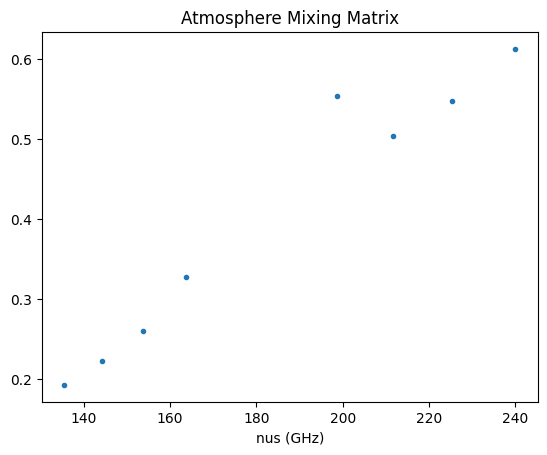

In [4]:
mixing_matrix = np.ones((params["nsub_in"], 2))
# Atm mixing matrix
mixing_matrix[:, 1] = atm.temperature * atm.integrated_abs_spectrum * atm.mean_water_vapor_density
print(mixing_matrix.shape)

plt.plot(atm.frequencies, mixing_matrix[:, 1], ".")
plt.xlabel("nus (GHz)")
plt.title("Atmosphere Mixing Matrix")
plt.show()

## Build local sampling

In [5]:
### Sweeping pointing
qubic_dict["date_obs"] = "2023-10-01 22:57:00.000"
qubic_dict["fix_azimuth"]["apply"] = False

qubic_dict["random_pointing"] = False
qubic_dict["sweeping_pointing"] = True

qubic_dict["angspeed"] = 0.1
qubic_dict["delta_az"] = 20
qubic_dict["nsweeps_per_elevation"] = 1
qubic_dict["duration"] = 1
# npointings = 3600 * qubic_dict['duration'] / qubic_dict['period']
qubic_dict["period"] = 3600 * qubic_dict["duration"] / params["npointings"]
print("Period :", qubic_dict["period"])

### Build scanning strategy instance
q_sampling_gal = get_pointing(qubic_dict)
qubic_patch = np.array([0, -57])
center_gal = equ2gal(qubic_patch[0], qubic_patch[1])
center_local = np.array([np.mean(q_sampling_gal.azimuth), np.mean(q_sampling_gal.elevation)])

wind_class = WindPerturbation(params, q_sampling_gal)
q_sampling_local = wind_class.get_deviated_qubic_sampling()

Period : 7.2


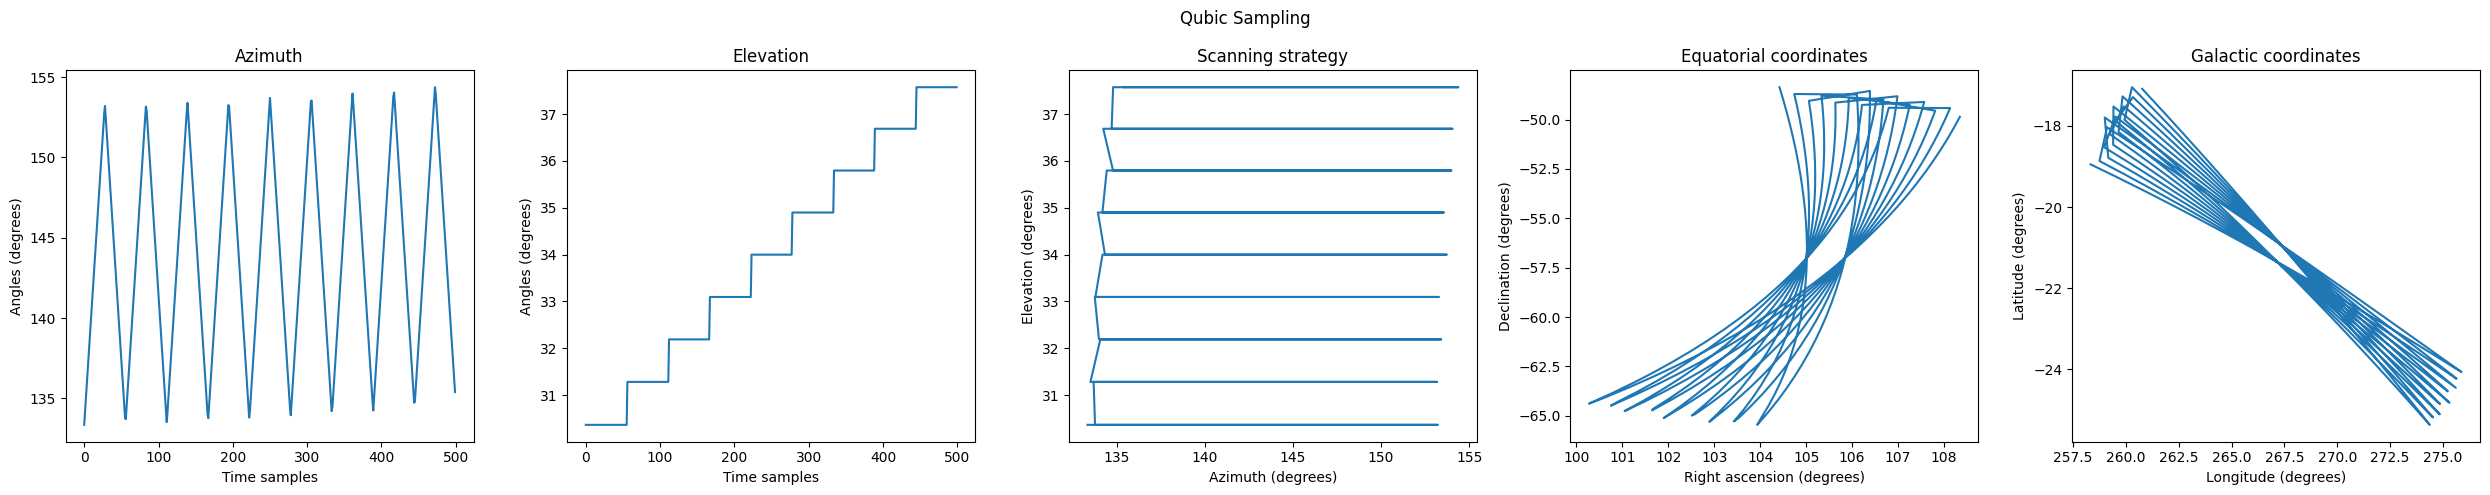

In [6]:
### Plot scanning strategy
az, el = q_sampling_local.azimuth, q_sampling_local.elevation

fig, axs = plt.subplots(1, 5, figsize=(25, 5))

# Azimuth plot
axs[0].plot(az)
axs[0].set_title("Azimuth")
axs[0].set_xlabel("Time samples")
axs[0].set_ylabel("Angles (degrees)")

# Elevation plot
axs[1].plot(el)
axs[1].set_title("Elevation")
axs[1].set_xlabel("Time samples")
axs[1].set_ylabel("Angles (degrees)")

# Scanning strategy plot
axs[2].plot(az, el)
axs[2].set_title("Scanning strategy")
axs[2].set_xlabel("Azimuth (degrees)")
axs[2].set_ylabel("Elevation (degrees)")

# Equatorial coordinates plot
axs[3].plot(
    (q_sampling_local.equatorial[:, 0] + 180) % 360 - 180, q_sampling_local.equatorial[:, 1]
)
axs[3].set_title("Equatorial coordinates")
axs[3].set_xlabel("Right ascension (degrees)")
axs[3].set_ylabel("Declination (degrees)")

# Galactic coordinates plot
axs[4].plot(q_sampling_local.galactic[:, 0], q_sampling_local.galactic[:, 1])
axs[4].set_title("Galactic coordinates")
axs[4].set_xlabel("Longitude (degrees)")
axs[4].set_ylabel("Latitude (degrees)")

fig.suptitle("Qubic Sampling")
plt.tight_layout()
plt.show()

143.80975773846924 33.98045926147831


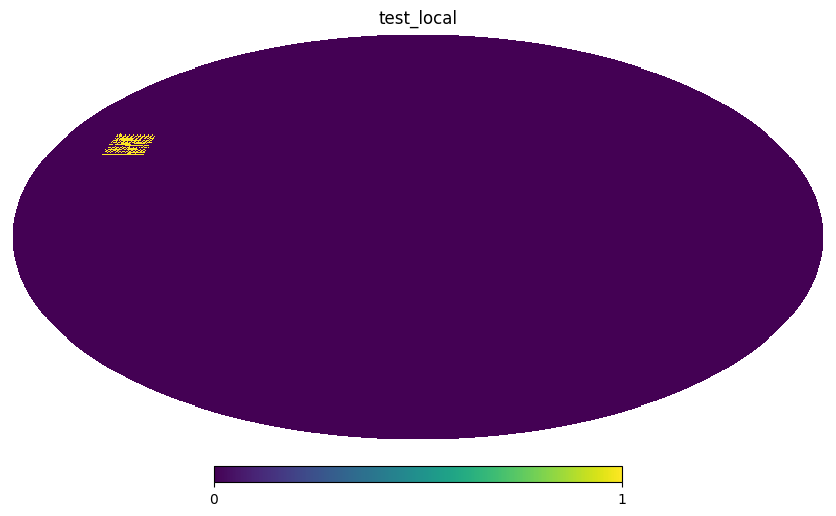

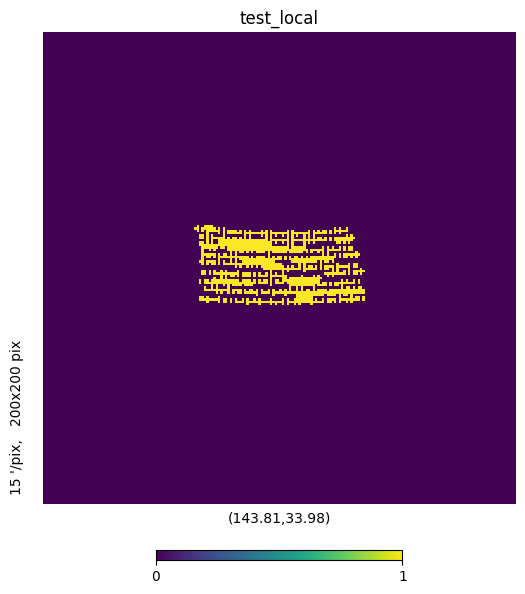

In [7]:
test_gal = np.zeros(hp.nside2npix(params["nside"]))

index = np.array(
    Spherical2HealpixOperator(params["nside"], "azimuth, elevation")(
        np.radians([q_sampling_local.azimuth, q_sampling_local.elevation]).T
    ),
    dtype="int",
)
test_gal[index] = 1
hp.mollview(test_gal, title="test_local", cmap="viridis")
hp.gnomview(
    test_gal,
    title="test_local",
    cmap="viridis",
    reso=15,
    rot=(np.mean(q_sampling_local.azimuth), np.mean(q_sampling_local.elevation)),
)

print(np.mean(q_sampling_local.azimuth), np.mean(q_sampling_local.elevation))

## Build 1 pointing sampling list

In [8]:
print(q_sampling_local)

QubicSampling((500,), 
    index=[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15 ,
    angle_hwp=[ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. ,
    azimuth=[133.34925326 134.06960267 134.78996052 135.51032682 136.23070157,
    elevation=[30.36705573 30.36705573 30.36705573 30.36705573 30.36705573 30.3,
    equatorial=[[104.41985034 -48.3644855 ]
 [104.49950661 -48.98514252]
 [104.5,
    galactic=[[258.3290554  -18.94709009]
 [258.96570627 -19.10752487]
 [259.6,
    masked=False,
    pitch=[-10.    -9.28  -8.56  -7.84  -7.12  -6.4   -5.68  -4.96  -4.24  ,
    time=[   0.     7.2   14.4   21.6   28.8   36.    43.2   50.4   57.6  )


In [9]:
q_sampling = []

N_buffer = 10

for ipointing in range(int(params["npointings"] / N_buffer)):
    tmp = QubicSampling(N_buffer)
    tmp.azimuth = q_sampling_gal.azimuth[ipointing * N_buffer : (ipointing + 1) * N_buffer]
    tmp.elevation = q_sampling_gal.elevation[ipointing * N_buffer : (ipointing + 1) * N_buffer]
    tmp.pitch = q_sampling_gal.pitch[ipointing * N_buffer : (ipointing + 1) * N_buffer]
    tmp.angle_hwp = q_sampling_gal.angle_hwp[ipointing * N_buffer : (ipointing + 1) * N_buffer]
    tmp.fix_az = True
    q_sampling.append(tmp)

# Atm

(8, 196608, 3)


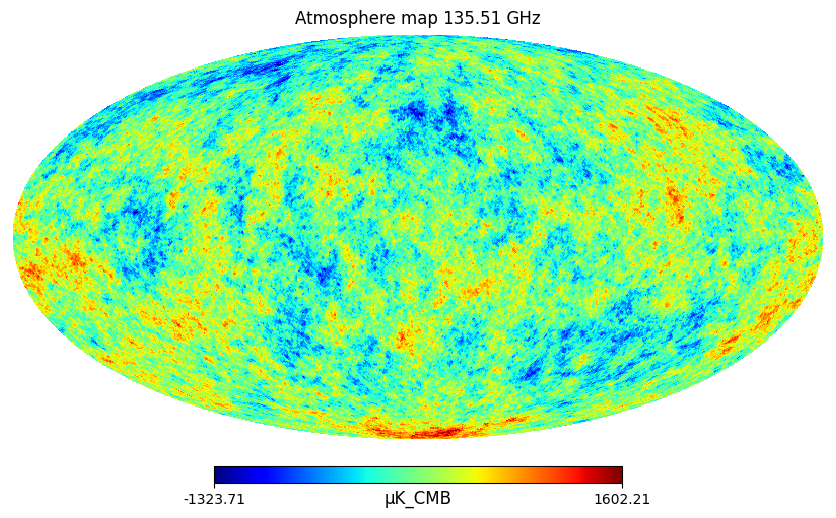

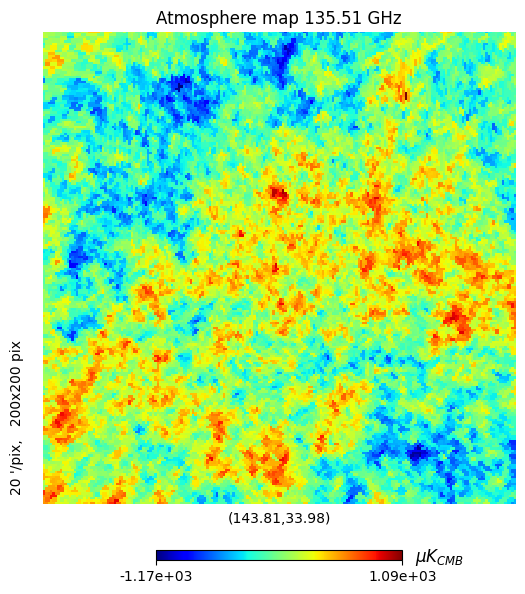

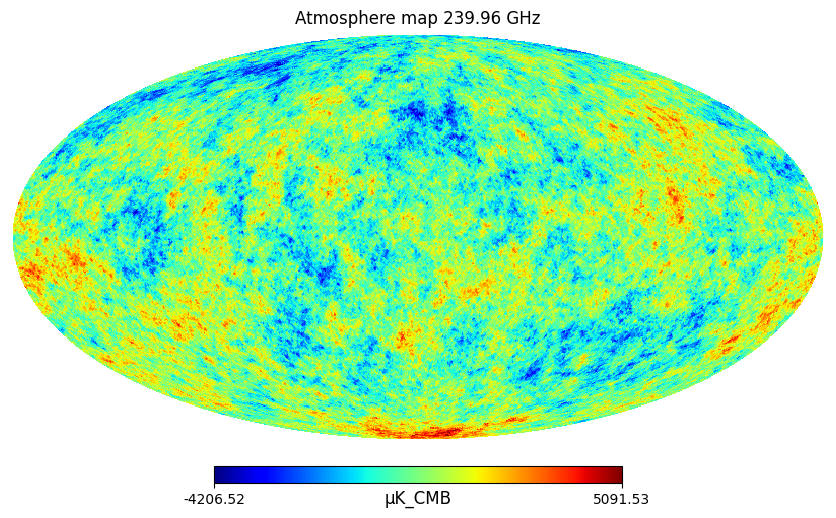

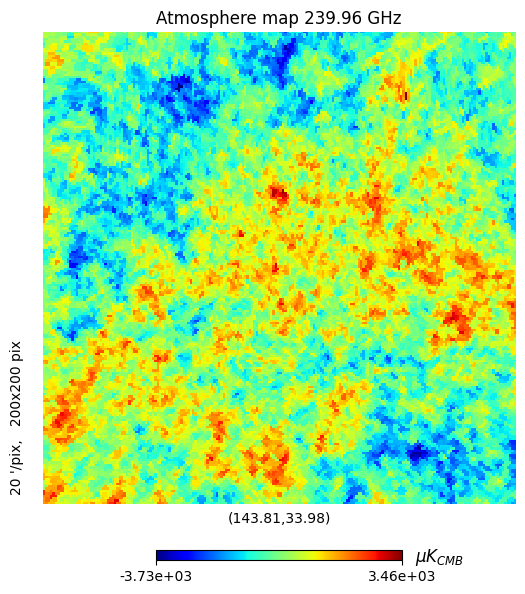

In [10]:
atm_maps = np.zeros((params["nsub_in"], hp.nside2npix(params["nside"]), 3))
atm_maps[..., 0] = atm.get_temp_maps(atm.delta_rho_map) / 1e3
print(atm_maps.shape)

index_nu = 0
hp.mollview(
    atm_maps[index_nu, :, 0],
    cmap="jet",
    unit="µK_CMB",
    title="Atmosphere map {:.2f} GHz".format(atm.frequencies[index_nu]),
)
hp.gnomview(
    atm_maps[index_nu, :, 0],
    rot=center_local,
    reso=20,
    title="Atmosphere map {:.2f} GHz".format(atm.frequencies[index_nu]),
    unit=r"$µK_{CMB}$",
    cmap="jet",
)

index_nu = -1
hp.mollview(
    atm_maps[index_nu, :, 0],
    cmap="jet",
    unit="µK_CMB",
    title="Atmosphere map {:.2f} GHz".format(atm.frequencies[index_nu]),
)
hp.gnomview(
    atm_maps[index_nu, :, 0],
    rot=center_local,
    reso=20,
    title="Atmosphere map {:.2f} GHz".format(atm.frequencies[index_nu]),
    unit=r"$µK_{CMB}$",
    cmap="jet",
)

In [11]:
true_maps = atm_maps.mean(axis=0)[None]
print(true_maps.shape)

min_input = np.min(true_maps, axis=1)
max_input = np.max(true_maps, axis=1)

max = np.max([min_input, max_input], axis=0)
min_input = -max
max_input = max

(1, 196608, 3)


# Map-making

## Tod acquisition

In [12]:
# Build the QUBIC operators
H_tod = QubicInstrumentType(
    atm.qubic_dict, nsub=params["nsub_in"], nrec=params["nsub_in"]
).get_operator()

tod = H_tod(atm_maps).ravel()

del H_tod

Info arch-laptop: Allocating (496000,9) elements = 68.115234375 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (496000,9) elements = 68.115234375 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (496000,9) elements = 68.115234375 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (496000,9) elements = 68.115234375 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (496000,9) elements = 68.115234375 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (496000,9) elements = 68.115234375 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (496000,9) elements = 68.115234375 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (496000,9) elements = 68.115234375 MiB in FSRRotation3dMatrix.__init__.


## Rec acquisition

In [13]:
Qacq = QubicInstrumentType(
    qubic_dict, params["nsub_in"], params["nsub_in"], sampling=q_sampling_local
)

# 1 pointing acq
H_rec = []
invN_rec = []

for ipointing in range(int(params["npointings"] / N_buffer)):
    tmp = QubicInstrumentType(
        qubic_dict, params["nsub_rec"], params["nsub_rec"], sampling=q_sampling[ipointing]
    )
    H_rec.append(tmp.get_operator())
    invN_rec.append(tmp.get_invntt_operator(params["wdet"], params["wpho150"], params["wpho220"]))

Info arch-laptop: Allocating (496000,9) elements = 68.115234375 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (496000,9) elements = 68.115234375 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (496000,9) elements = 68.115234375 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (496000,9) elements = 68.115234375 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (496000,9) elements = 68.115234375 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (496000,9) elements = 68.115234375 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (496000,9) elements = 68.115234375 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (496000,9) elements = 68.115234375 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (9920,9) elements = 1.3623046875 MiB in FSRRotation3dMatrix.__init__.
Info arch-laptop: Allocating (9920,9) elements = 1.3623046875 MiB in FSRRotation3dMatrix.__in

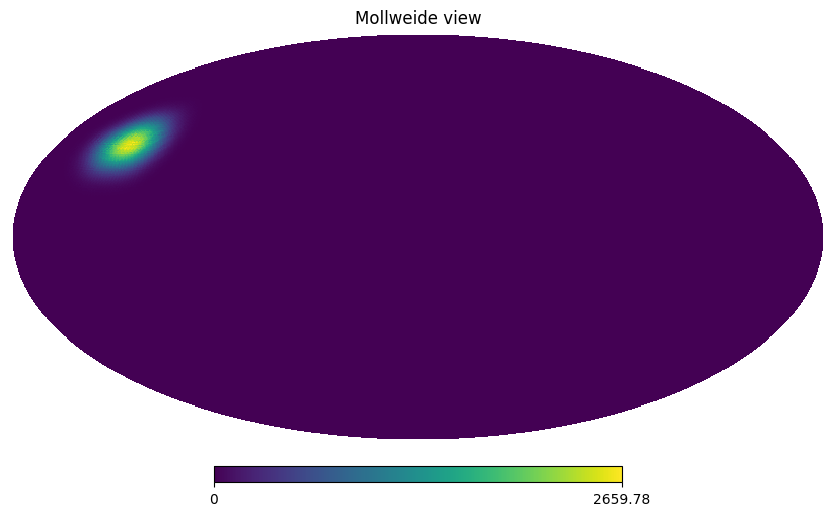

In [14]:
coverage = Qacq.coverage

covnorm = coverage / coverage.max()
seenpix = covnorm > params["coverage_cut"]

hp.mollview(coverage)

# Wind Operator

In [15]:
wind = wind_class.get_constant_wind(params["wind_cst"][0], params["wind_cst"][1])
print("wind_x :", wind[0].shape)
wind = np.array(wind)
print("wind :", wind.shape)

@flags.symmetric
class ShiftOperator(Operator):
    def __init__(self, wind, dtype = None, **keywords):
        self.wind = wind
        Operator.__init__(self, dtype=dtype, **keywords)
    def direct(self, map, out):
        wind_x, wind_y = self.wind

        dx = -np.round(wind_x).astype(int)
        dy = -np.round(wind_y).astype(int)
        out = np.roll(map, (dx, dy), axis=(0, 1))

tmp = [ShiftOperator(wind=wind.T[i], shapein=(params["nsub_rec"], npix, 3), shapeout=(params["nsub_rec"], npix, 3)) for i in range(0, params["npointings"],  N_buffer)]
shift = BlockColumnOperator(
    tmp,
    axisout=0
)
print("shift :", shift.shapein, shift.shapeout)

wind_x : (500,)
wind : (2, 500)
shift : (8, 196608, 3) (400, 196608, 3)


In [ ]:
def get_wind_operator(wind, npointings=params["npointings"], N_buffer=N_buffer):
    wind_x, wind_y = wind
    wind_cst = np.array(wind_class.get_constant_wind(wind_x, wind_y))
    
    tmp = [ShiftOperator(wind=wind_cst.T[i], shapein=(params["nsub_rec"], npix, 3), shapeout=(params["nsub_rec"], npix, 3)) for i in range(0, params["npointings"],  N_buffer)]
    return BlockColumnOperator(
    tmp,
    axisout=0
)
    

# Rec Operator

In [16]:
A = (
    DenseOperator(
        mixing_matrix[:, 1, None],
        broadcast="rightward",
        shapein=(1, npix, 3),
        shapeout=(params["nsub_in"], npix, 3),
    )
)
print("A :", A.shapein, A.shapeout)

A : (1, 196608, 3) (8, 196608, 3)


In [17]:
H = BlockDiagonalOperator(H_rec, axisin=0) * shift * A
R = ReshapeOperator((int(params["npointings"] / N_buffer) * 992, N_buffer), (int(params["npointings"] / N_buffer) * 992 * N_buffer))
invN = R * BlockDiagonalOperator(invN_rec, axisout=0) * R.T
print("H :", H.shapein, H.shapeout)
print("invN :", invN.shapein, invN.shapeout)

ValueError: The input shape (49600, 10) of 496000←(49600,10) is incompatible with (50, 992, 10).

# Map-Making

In [ ]:
# Build PCG
R = ReshapeOperator(tod.shape, H.shapeout)
A = H.T * invN * H
b = H.T * invN * R(tod)
x0 = true_maps * 0.0

In [ ]:
print("A", A.shapein, A.shapeout)
print("b", b.shape)
print("x0", x0.shape)

A (1, 196608, 3) (1, 196608, 3)
b (1, 196608, 3)
x0 (1, 196608, 3)


In [ ]:
# Run PCG
algo = PCGAlgorithm(
    A,
    b,
    comm,
    x0=x0,
    tol=1e-10,
    maxiter=20,
    disp=True,
    M=None,
    center=[0, -57],
    reso=15,
    seenpix=seenpix,
    input=true_maps,
)
try:
    output = algo.run()
    success = True
    message = "Success"
except AbnormalStopIteration as e:
    output = algo.finalize()
    success = False
    message = str(e)

 Iter     Tol      time
   1: 1.5567e+13 6.87718 [0. 0. 0.]
   2: 2.9404e+16 6.93224 [0. 0. 0.]
   3: 6.0941e+16 6.85680 [0. 0. 0.]
   4: 9.3755e+16 6.88614 [0. 0. 0.]
   5: 1.2180e+17 6.95199 [0. 0. 0.]
   6: 1.4688e+17 6.86760 [0. 0. 0.]
   7: 1.7024e+17 6.80740 [0. 0. 0.]
   8: 1.9266e+17 6.90474 [0. 0. 0.]
   9: 2.1465e+17 6.94035 [0. 0. 0.]
  10: 2.3658e+17 6.91131 [0. 0. 0.]
  11: 2.5870e+17 7.09238 [0. 0. 0.]
  12: 2.8124e+17 7.04328 [0. 0. 0.]
  13: 3.0437e+17 6.85248 [0. 0. 0.]
  14: 3.2823e+17 6.95201 [0. 0. 0.]
  15: 3.5296e+17 6.92665 [0. 0. 0.]
  16: 3.7869e+17 6.92449 [0. 0. 0.]
  17: 4.0552e+17 6.86236 [0. 0. 0.]
  18: 4.3357e+17 6.88930 [0. 0. 0.]
  19: 4.6295e+17 6.97257 [0. 0. 0.]
  20: 4.9378e+17 6.90106 [0. 0. 0.]


# Convergence & Plot

Text(0, 0.5, 'Convergence')

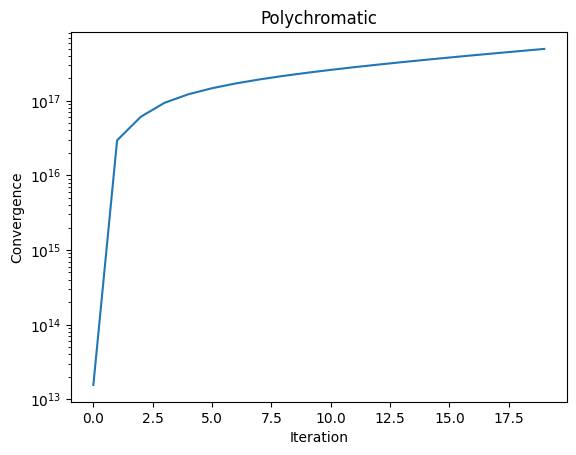

In [ ]:
plt.plot(output["convergence"])
plt.title("Polychromatic")
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Convergence")

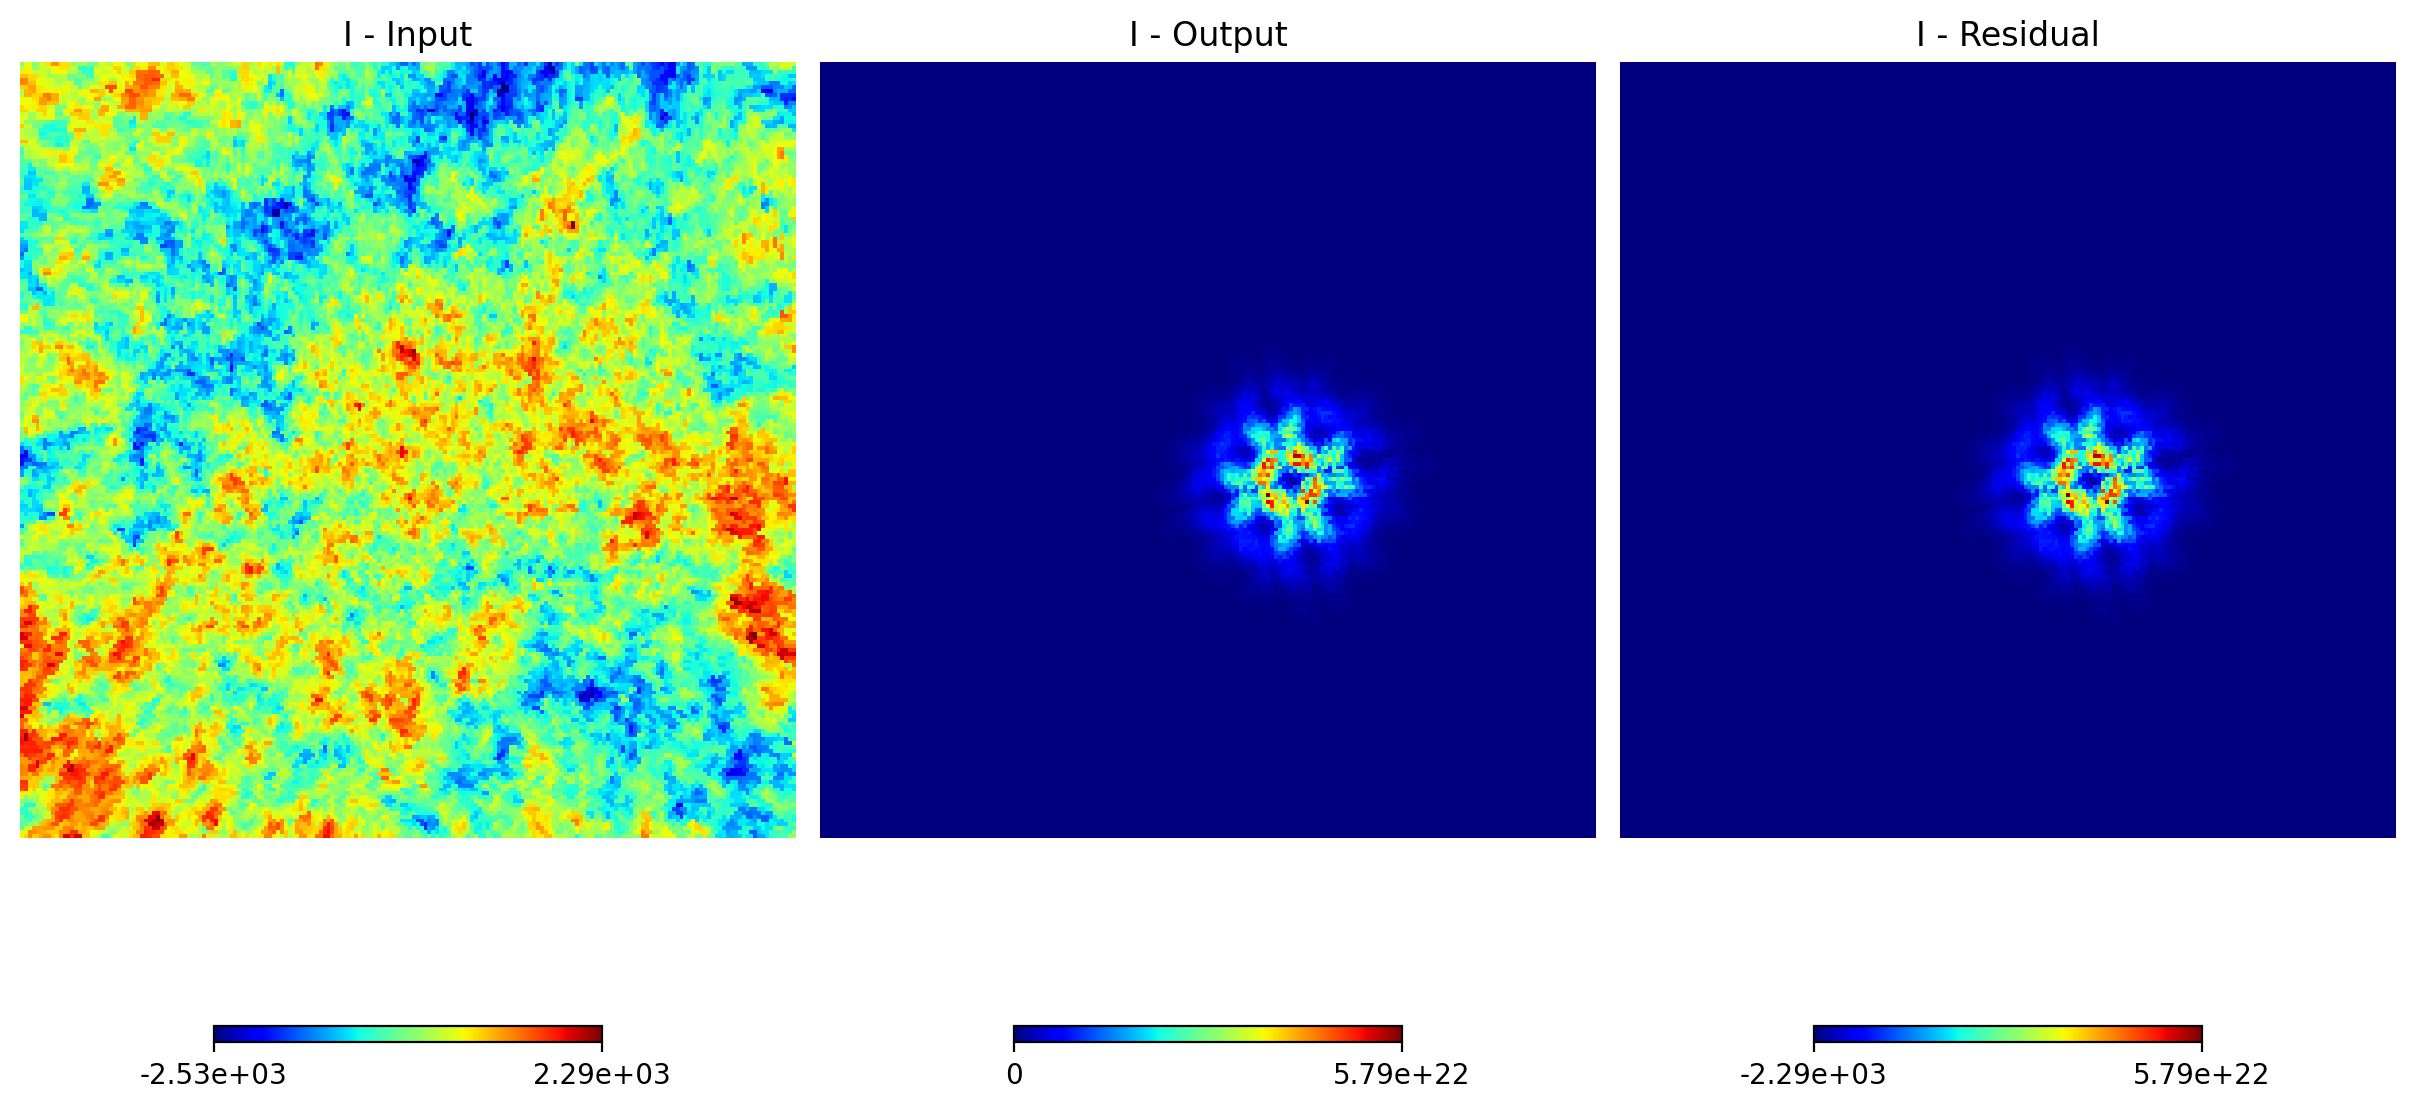

In [ ]:
plt.figure(figsize=(12, 12), dpi=200)
k = 1
# true_maps[:, ~seenpix, :] = hp.UNSEEN
# output['x'][:, ~seenpix, :] = hp.UNSEEN

stk = ["I", "Q", "U"]
istk = 0
n_sig = 3
reso = 25

for inu in range(output["x"].shape[0]):
    sigma = np.std(true_maps[inu, seenpix, istk])
    hp.gnomview(
        true_maps[inu, :, istk],
        cmap="jet",
        rot=center_local,
        title="{} - Input".format(stk[istk]),
        reso=reso,
        sub=(output["x"].shape[0], 3, k),
        notext=True,
    )
    hp.gnomview(
        output["x"][inu, :, istk],
        cmap="jet",
        rot=center_local,
        title="{} - Output".format(stk[istk]),
        reso=reso,
        sub=(output["x"].shape[0], 3, k + 1),
        notext=True,
    )
    hp.gnomview(
        output["x"][inu, :, istk] - true_maps[inu, :, istk],
        cmap="jet",
        rot=center_local,
        title="{} - Residual".format(stk[istk]),
        reso=reso,
        sub=(output["x"].shape[0], 3, k + 2),
        notext=True,
    )
    k += 3

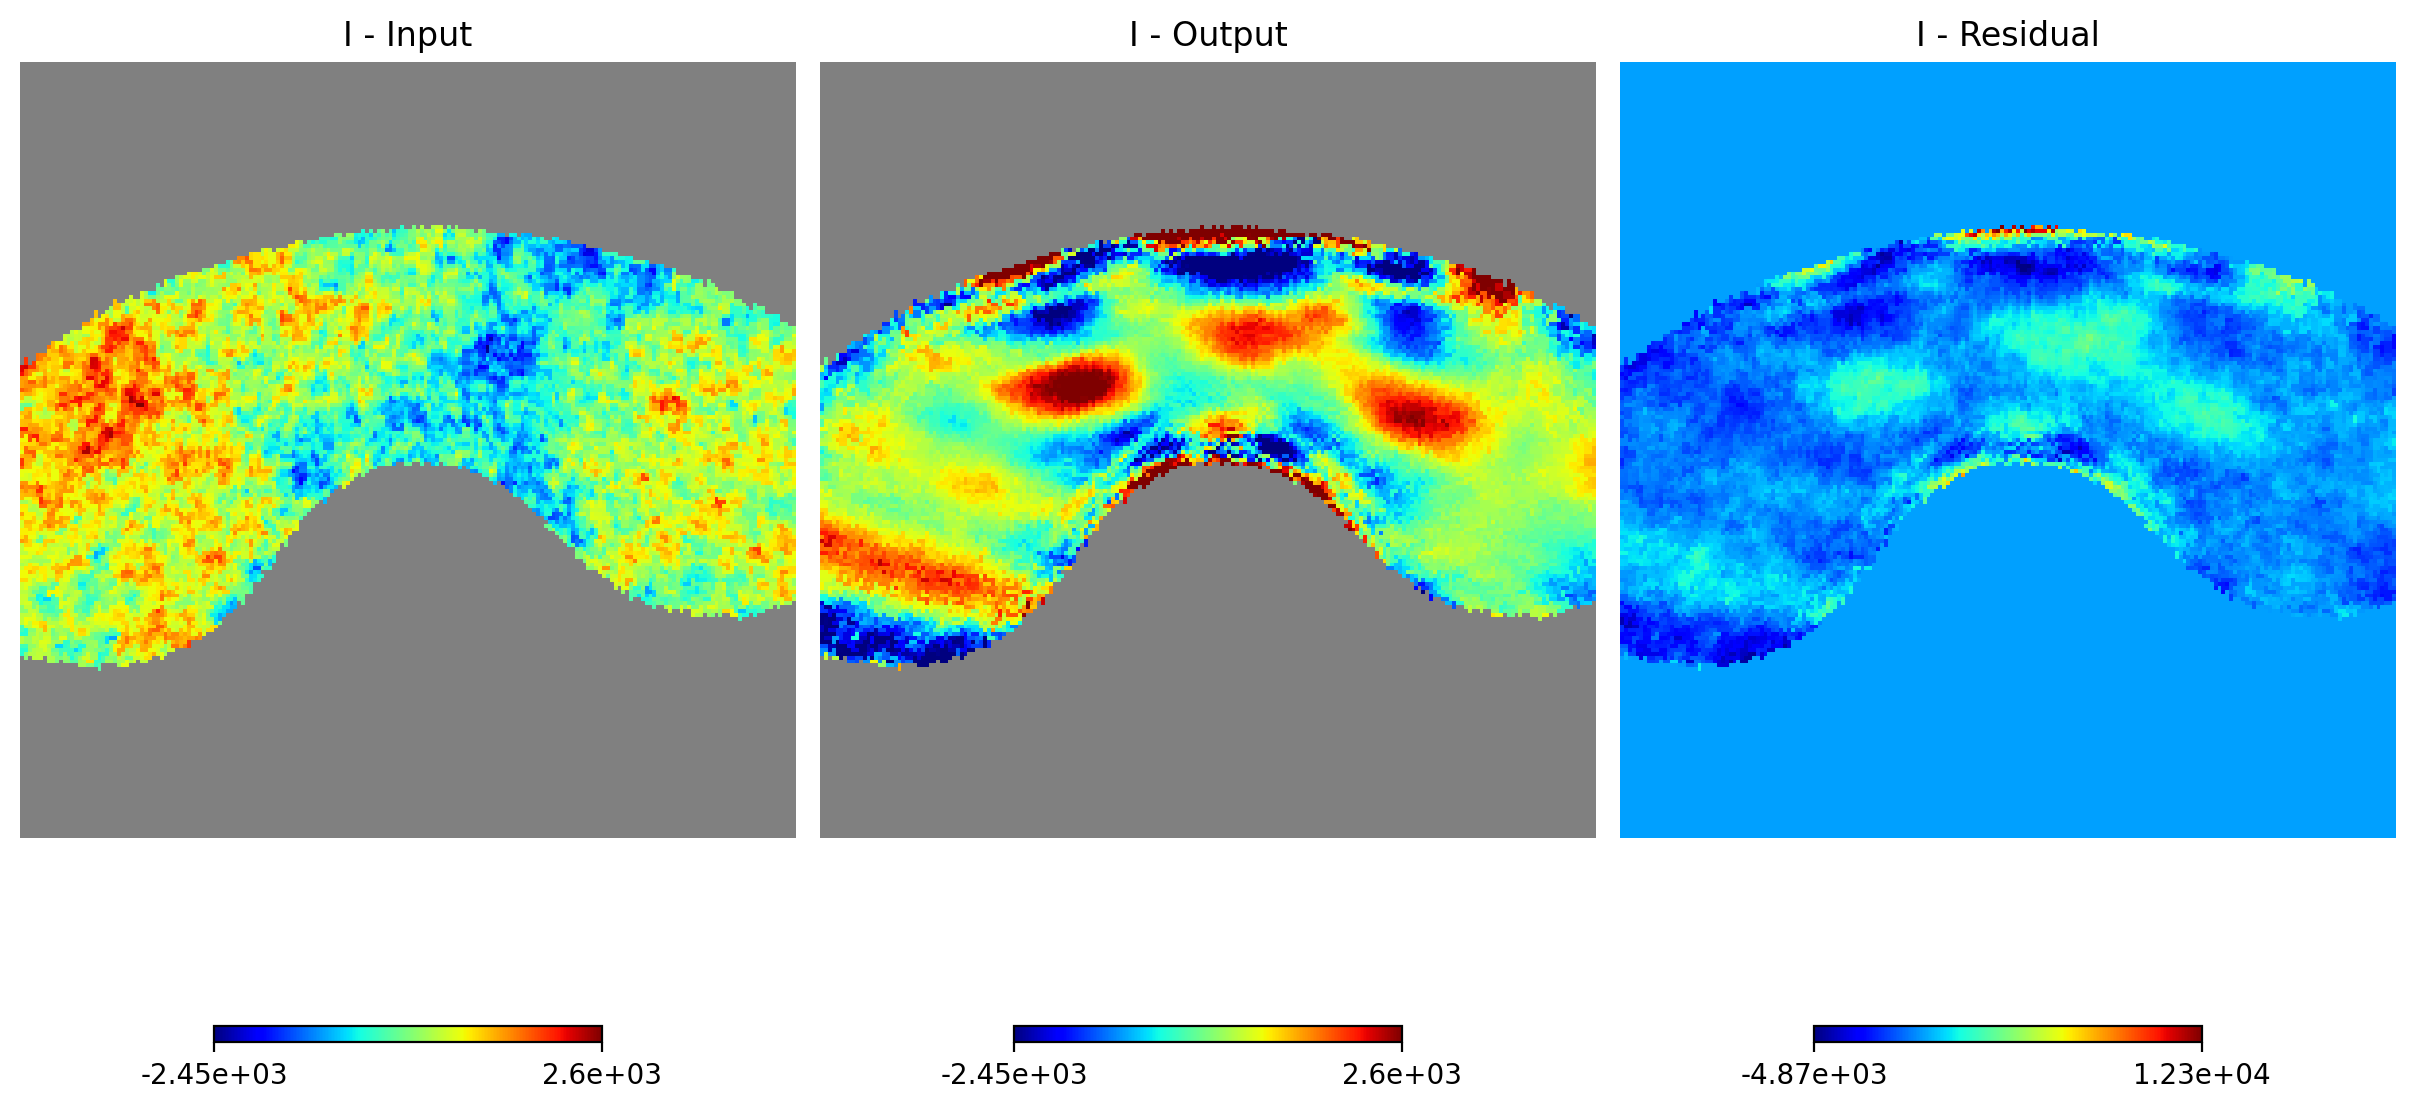

In [ ]:
plt.figure(figsize=(12, 12), dpi=200)
k = 1
true_maps[:, ~seenpix, :] = hp.UNSEEN
output["x"][:, ~seenpix, :] = hp.UNSEEN

stk = ["I", "Q", "U"]
istk = 0
n_sig = 3
reso = 25

for inu in range(output["x"].shape[0]):
    sigma = np.std(true_maps[inu, seenpix, istk])
    hp.gnomview(
        true_maps[inu, :, istk],
        min=np.min(true_maps[inu, seenpix, istk]),
        max=np.max(true_maps[inu, seenpix, istk]),
        cmap="jet",
        rot=center_local,
        title="{} - Input".format(stk[istk]),
        reso=reso,
        sub=(output["x"].shape[0], 3, k),
        notext=True,
    )
    hp.gnomview(
        output["x"][inu, :, istk],
        min=np.min(true_maps[inu, seenpix, istk]),
        max=np.max(true_maps[inu, seenpix, istk]),
        cmap="jet",
        rot=center_local,
        title="{} - Output".format(stk[istk]),
        reso=reso,
        sub=(output["x"].shape[0], 3, k + 1),
        notext=True,
    )
    hp.gnomview(
        output["x"][inu, :, istk] - true_maps[inu, :, 0],
        cmap="jet",
        rot=center_local,
        title="{} - Residual".format(stk[istk]),
        reso=reso,
        sub=(output["x"].shape[0], 3, k + 2),
        notext=True,
    )
    k += 3

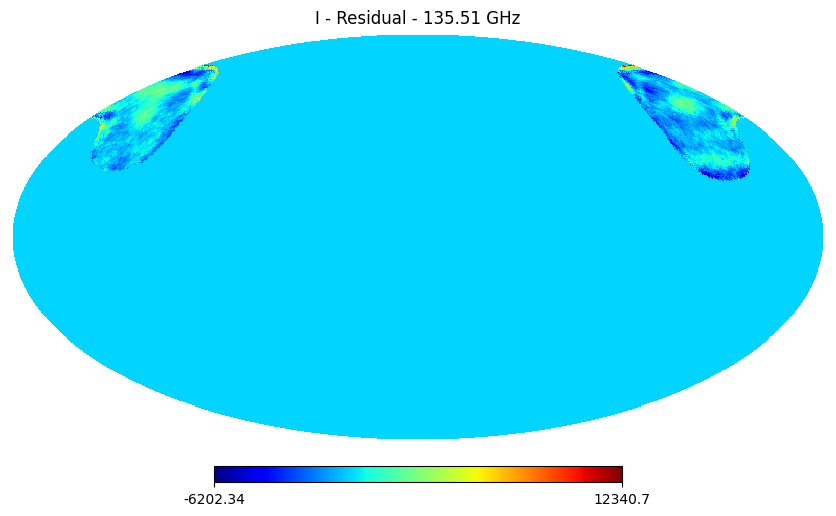

In [ ]:
for inu in range(output["x"].shape[0]):
    sigma = np.std(true_maps[inu, seenpix, istk])
    hp.mollview(
        output["x"][inu, :, istk] - true_maps[inu, :, istk],
        cmap="jet",
        title="{} - Residual - {:.2f} GHz".format(stk[istk], atm.frequencies[inu]),
    )

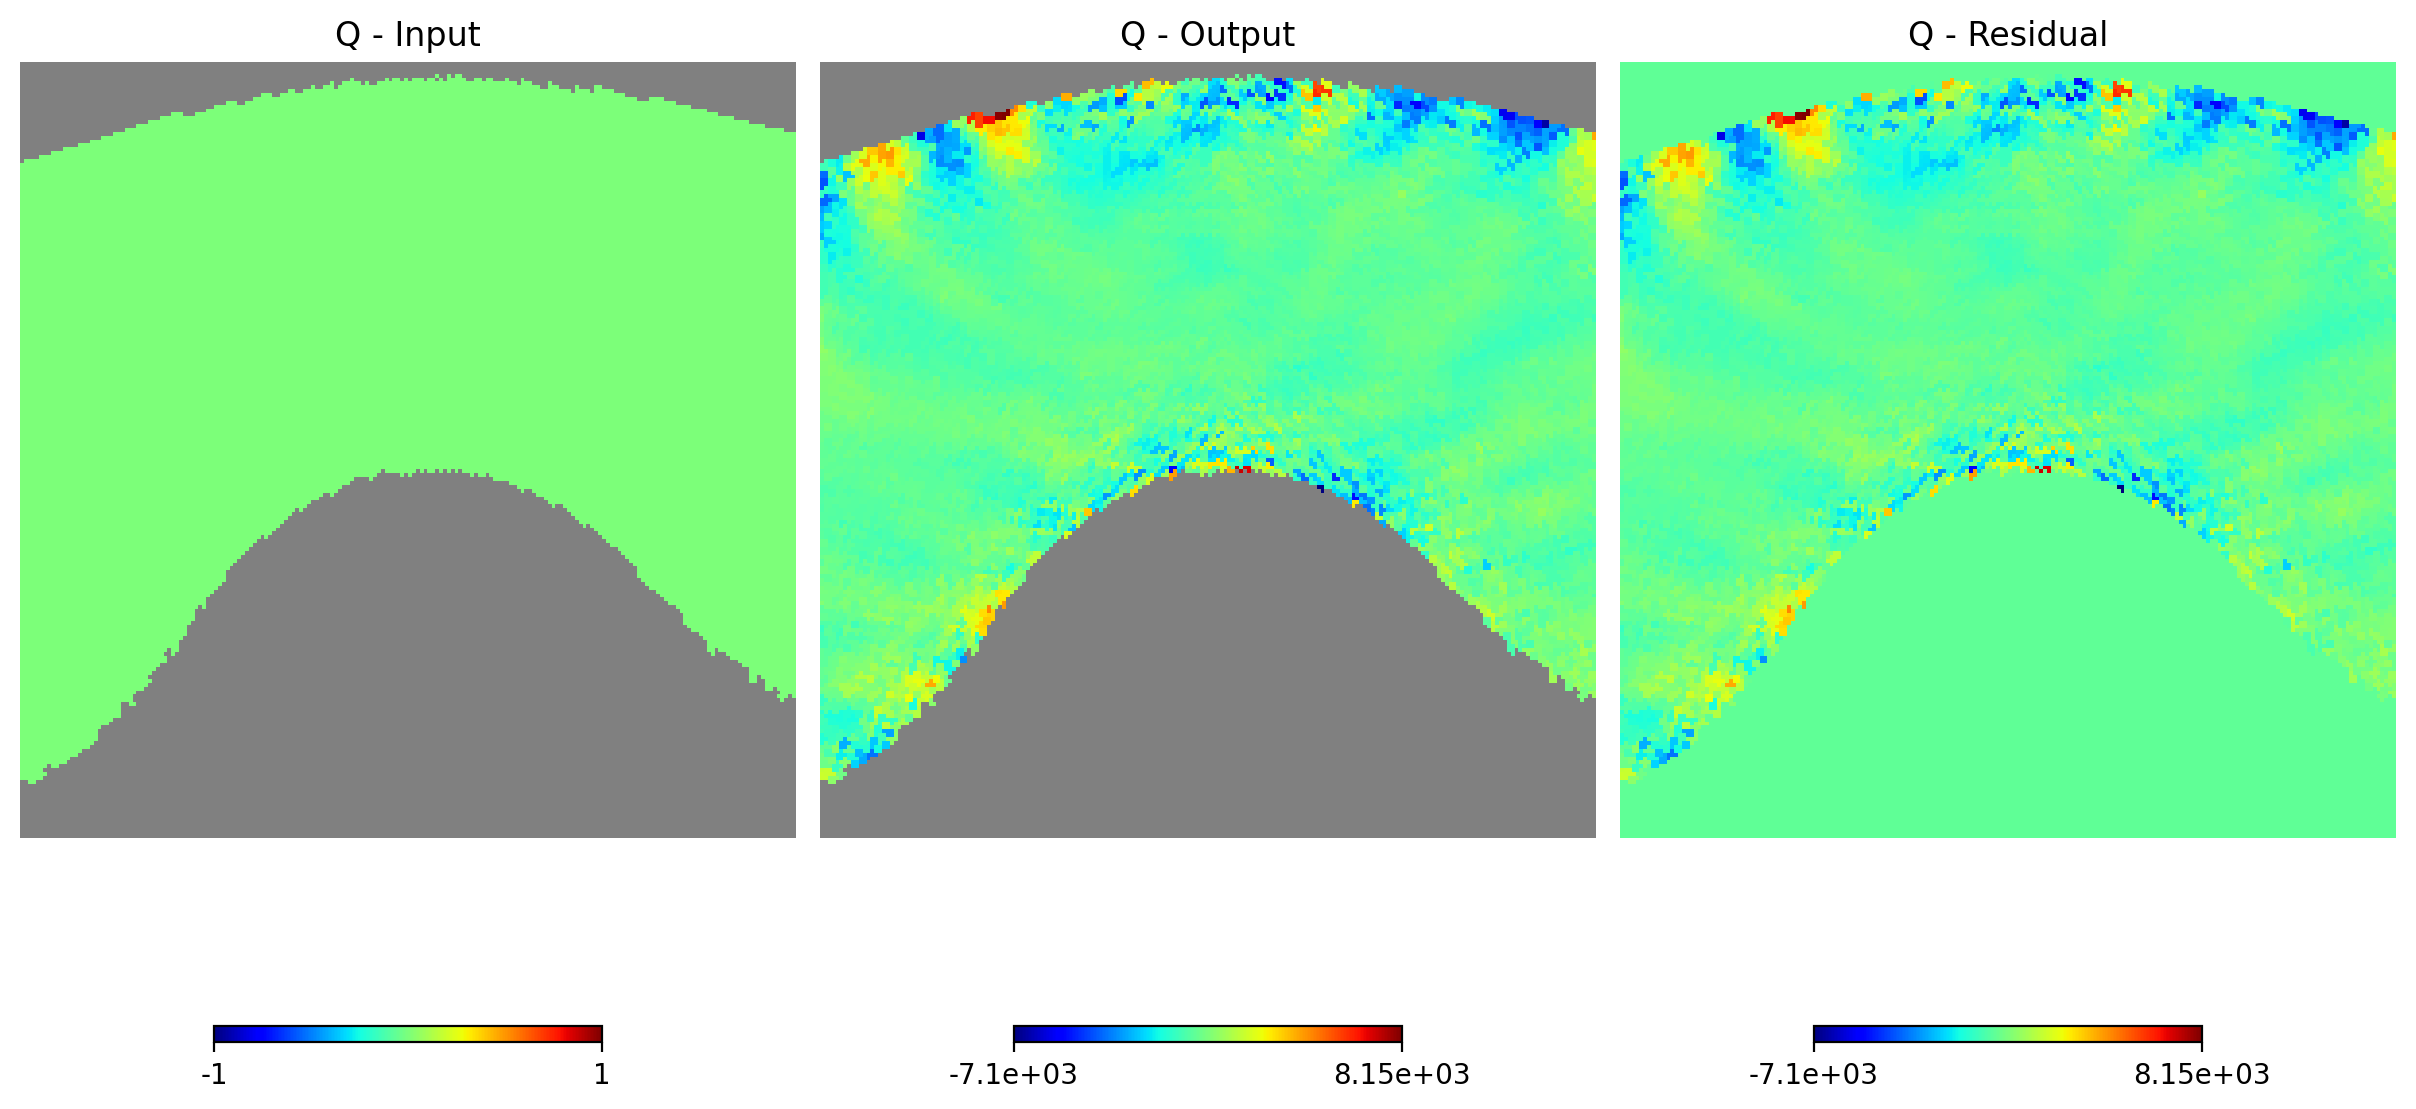

In [ ]:
plt.figure(figsize=(12, 12), dpi=200)

k = 1

istk = 1
n_sig = 2

for inu in range(output["x"].shape[0]):
    sigma = np.std(true_maps[inu, seenpix, istk])
    hp.gnomview(
        true_maps[inu, :, istk],
        cmap="jet",
        rot=center_local,
        title="{} - Input".format(stk[istk]),
        reso=15,
        sub=(output["x"].shape[0], 3, k),
        notext=True,
    )
    hp.gnomview(
        output["x"][inu, :, istk],
        cmap="jet",
        rot=center_local,
        title="{} - Output".format(stk[istk]),
        reso=15,
        sub=(output["x"].shape[0], 3, k + 1),
        notext=True,
    )
    hp.gnomview(
        output["x"][inu, :, istk] - true_maps[inu, :, istk],
        cmap="jet",
        rot=center_local,
        title="{} - Residual".format(stk[istk]),
        reso=15,
        sub=(output["x"].shape[0], 3, k + 2),
        notext=True,
    )
    k += 3